# 06 — ABC Analysis

## GulfMart Retail Inventory Analytics

Classic ABC analysis, plus a cross-tabulation against the excess-value
tiers from `05_overstock_analysis.ipynb`, to directly answer this
project's stated ABC goal: not "which products sell the most" but
**"which products deserve the most inventory-management attention."**

**Classification basis:** products are classified by **annual COGS**
("annual dollar usage") -- the standard inventory-management ABC metric
-- rather than revenue. This keeps the lens consistent with every prior
notebook (turnover, GMROI, excess value are all inventory-investment
framed, not revenue-framed).

```text
A: cumulative share of total annual COGS up to 80%
B: cumulative share from 80% to 95%
C: cumulative share from 95% to 100%
```

**The priority matrix:** ABC class (by COGS) is cross-tabulated against
an excess-value tier (High/Medium/Low, computed with the *same* generic
cumulative-threshold method applied to `05_overstock_analysis.ipynb`'s
average excess value per product) -- one technique, applied twice.

```text
              Low Excess      Medium Excess     High Excess
A (high COGS)  Healthy A       Watch A           Urgent
B              Healthy B       Watch B           Priority cleanup
C (low COGS)   Fine as-is      Low priority      Classic dead weight
```

Products with zero annual COGS (no recorded sales -- 4 products,
confirmed in `01_data_profiling.ipynb` and `03_inventory_kpis.ipynb`)
are explicitly kept in this analysis and forced into class C rather
than silently dropped, since they are a real and relevant finding, not
missing data.


## 1. Setup

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
SRC_DIR = PROJECT_ROOT / "src"
DATA_RAW_DIR = PROJECT_ROOT / "data" / "raw"
DATA_CLEANED_DIR = PROJECT_ROOT / "data" / "cleaned"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from abc_analysis import (
    compute_annual_cogs_by_product,
    classify_by_value,
    build_priority_matrix,
)
from overstock_analysis import compute_excess_value, summarize_excess_by

print(f"Project root: {PROJECT_ROOT}")


Project root: d:\GitHub\retail-inventory-analytics


## 2. Load Data

In [2]:
dim_product = pd.read_csv(DATA_CLEANED_DIR / "dim_product.csv")
fact_sales = pd.read_csv(DATA_CLEANED_DIR / "fact_sales.csv")
fact_inventory = pd.read_csv(DATA_RAW_DIR / "fact_inventory.csv.gz")

print(f"dim_product:    {len(dim_product):,} rows")
print(f"fact_sales:     {len(fact_sales):,} rows")
print(f"fact_inventory: {len(fact_inventory):,} rows")


dim_product:    500 rows
fact_sales:     125,000 rows
fact_inventory: 10,960,000 rows


## 3. Classify Products by Annual COGS (ABC)

`period_days` is taken from `fact_inventory["date"].nunique()` for
consistency with the annualization convention already used in
`03_inventory_kpis.ipynb`.

In [3]:
period_days = fact_inventory["date"].nunique()

product_cogs = compute_annual_cogs_by_product(fact_sales, period_days=period_days)

# Products with zero recorded sales never appear in fact_sales at all --
# reindex against the full product catalog so they are explicitly
# present with annual_cogs = 0, not silently dropped from the analysis.
product_cogs_full = (
    dim_product[["product_id"]]
    .merge(product_cogs[["product_id", "annual_cogs"]], on="product_id", how="left")
)
product_cogs_full["annual_cogs"] = product_cogs_full["annual_cogs"].fillna(0)

zero_cogs_products = (product_cogs_full["annual_cogs"] == 0).sum()
print(f"Products with zero annual COGS (no sales): {zero_cogs_products:,}")

abc_classified = classify_by_value(
    product_cogs_full,
    value_column="annual_cogs",
    id_column="product_id",
    thresholds=(0.80, 0.95),
    labels=("A", "B", "C"),
)

abc_classified = abc_classified.rename(columns={
    "value_share_pct": "cogs_share_pct",
    "cumulative_share_pct": "cogs_cumulative_pct",
})

print()
print("ABC class distribution (product count):")
print(abc_classified["annual_cogs_class"].value_counts().reindex(["A", "B", "C"]))



Computing Annual COGS by Product
Products with sales: 496
Total annual COGS (all products): 43,981,216.91
Products with zero annual COGS (no sales): 4

ABC class distribution (product count):
annual_cogs_class
A     51
B    105
C    344
Name: count, dtype: int64


In [4]:
class_cogs_share = abc_classified.groupby("annual_cogs_class")["annual_cogs"].sum()
total_cogs = class_cogs_share.sum()

print("Share of total annual COGS by class:")
for cls in ["A", "B", "C"]:
    share = class_cogs_share.get(cls, 0) / total_cogs * 100
    count = (abc_classified["annual_cogs_class"] == cls).sum()
    print(f"  Class {cls}: {count:>3} products ({count/len(abc_classified):.1%}) -> {share:.1f}% of annual COGS")


Share of total annual COGS by class:
  Class A:  51 products (10.2%) -> 79.4% of annual COGS
  Class B: 105 products (21.0%) -> 15.6% of annual COGS
  Class C: 344 products (68.8%) -> 5.0% of annual COGS


## 4. Classify Products by Excess-Value Tier

Reuses `compute_excess_value()` and `summarize_excess_by()` from
`05_overstock_analysis.ipynb`'s module directly, then applies the same
`classify_by_value()` function used for ABC above -- one technique, two
dimensions.

In [5]:
fact_inventory_excess = compute_excess_value(fact_inventory, dim_product)

product_excess = summarize_excess_by(fact_inventory_excess, "product_id").reset_index()

excess_classified = classify_by_value(
    product_excess,
    value_column="avg_excess_value",
    id_column="product_id",
    thresholds=(0.80, 0.95),
    labels=("High", "Medium", "Low"),
)

excess_classified = excess_classified.rename(columns={
    "value_share_pct": "excess_share_pct",
    "cumulative_share_pct": "excess_cumulative_pct",
})

print("Excess-value tier distribution (product count):")
print(excess_classified["avg_excess_value_class"].value_counts().reindex(["High", "Medium", "Low"]))



Computing Excess Inventory Value
Rows: 10,960,000
Rows above target_stock_level: 10,883,556 (99.3%)
Total excess_value across all rows (period-cumulative, not a balance): 13,726,848,377,533.79
Excess-value tier distribution (product count):
avg_excess_value_class
High      152
Medium    132
Low       216
Name: count, dtype: int64


## 5. Merge Into a Single Classified Table

In [6]:
classified = abc_classified.merge(
    excess_classified[["product_id", "avg_excess_value", "excess_share_pct", "excess_cumulative_pct", "avg_excess_value_class"]],
    on="product_id",
    how="left",
)

classified = classified.merge(
    dim_product[["product_id", "product_name", "category", "demand_class"]],
    on="product_id",
    how="left",
)

classified.head()


,product_id,annual_cogs,cogs_share_pct,cogs_cumulative_pct,annual_cogs_class,avg_excess_value,excess_share_pct,excess_cumulative_pct,avg_excess_value_class,product_name,category,demand_class
0,PROD0062,1.587198e+06,3.608808,3.608808,A,1.406929e+08,1.123342,17.237876,High,Beauty Tools Product 0062,Beauty,Fast-moving
1,PROD0386,1.274074e+06,2.896858,6.505666,A,1.229505e+08,0.981680,23.397723,High,Water Product 0386,Beverages,Fast-moving
2,PROD0029,1.265858e+06,2.878180,9.383846,A,1.420296e+08,1.134014,16.114534,High,Oral Care Product 0029,Personal Care,Fast-moving
3,PROD0172,1.262918e+06,2.871494,12.255339,A,1.169816e+08,0.934023,29.109939,High,Storage Product 0172,Home & Living,Fast-moving
4,PROD0321,1.240784e+06,2.821168,15.076508,A,1.138888e+08,0.909328,30.019268,High,Children's Clothing Product 0321,Fashion,Fast-moving


## 6. Priority Matrix

In [7]:
count_matrix, labeled = build_priority_matrix(
    classified,
    abc_class_column="annual_cogs_class",
    excess_tier_column="avg_excess_value_class",
)



Building ABC x Excess-Tier Priority Matrix
avg_excess_value_class  High  Medium  Low
annual_cogs_class                        
A                         49       2    0
B                         46      53    6
C                         57      77  210


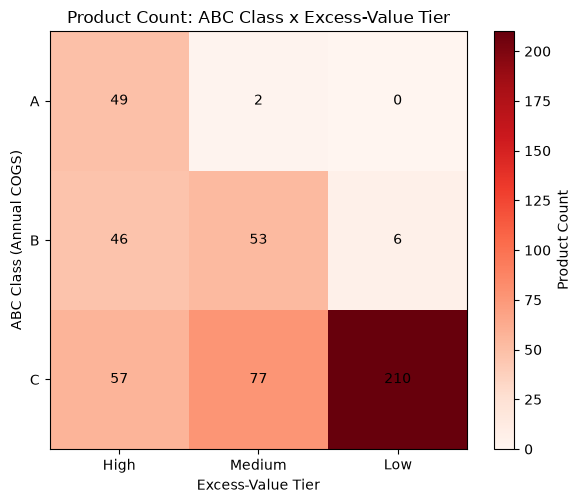

In [11]:
fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(count_matrix.values, cmap="Reds")

ax.set_xticks(range(len(count_matrix.columns)))
ax.set_xticklabels(count_matrix.columns)
ax.set_yticks(range(len(count_matrix.index)))
ax.set_yticklabels(count_matrix.index)
ax.set_xlabel("Excess-Value Tier")
ax.set_ylabel("ABC Class (Annual COGS)")
ax.set_title("Product Count: ABC Class x Excess-Value Tier")

for i in range(len(count_matrix.index)):
    for j in range(len(count_matrix.columns)):
        ax.text(j, i, count_matrix.values[i, j], ha="center", va="center", color="black")

plt.colorbar(im, ax=ax, label="Product Count")
plt.tight_layout()
plt.show()


## 7. Drill-Down: Highest-Priority Cells

**"C x High"** -- classic dead weight: low inventory-investment
importance, but high excess. Cheapest, easiest wins.

**"A x High"** -- urgent: products the business actually depends on,
also carrying large excess -- worth checking whether this is a genuine
problem or just a side effect of being high-volume.

In [9]:
c_high = labeled[
    (labeled["annual_cogs_class"] == "C") & (labeled["avg_excess_value_class"] == "High")
].sort_values("avg_excess_value", ascending=False)

print(f"'C x High' (dead weight) products: {len(c_high):,}")
print(
    c_high[["product_id", "product_name", "category", "annual_cogs", "avg_excess_value"]]
    .head(15)
    .to_string(index=False)
)


'C x High' (dead weight) products: 57
product_id                      product_name      category  annual_cogs  avg_excess_value
  PROD0122                Audio Product 0122   Electronics 10338.291971      1.908517e+08
  PROD0299         Canned Foods Product 0299       Grocery 17514.654881      1.263431e+08
  PROD0141        Rice & Grains Product 0141       Grocery 16450.576642      1.178088e+08
  PROD0126             Footwear Product 0126       Fashion 14040.191241      1.044633e+08
  PROD0459       Men's Clothing Product 0459       Fashion 17746.593066      9.528696e+07
  PROD0027  Children's Clothing Product 0027       Fashion 12617.457208      7.779922e+07
  PROD0232     Kitchen Supplies Product 0232     Household 20875.835310      7.554220e+07
  PROD0159       Men's Grooming Product 0159 Personal Care 19245.137865      7.288458e+07
  PROD0057            Hair Care Product 0057 Personal Care 19477.412409      7.209807e+07
  PROD0300           Home Decor Product 0300 Home & Living  66

In [10]:
a_high = labeled[
    (labeled["annual_cogs_class"] == "A") & (labeled["avg_excess_value_class"] == "High")
].sort_values("avg_excess_value", ascending=False)

print(f"'A x High' (urgent) products: {len(a_high):,}")
print(
    a_high[["product_id", "product_name", "category", "annual_cogs", "avg_excess_value"]]
    .head(15)
    .to_string(index=False)
    if len(a_high) > 0 else "(none)"
)


'A x High' (urgent) products: 49
product_id                       product_name      category  annual_cogs  avg_excess_value
  PROD0132               Laundry Product 0132     Household 5.359275e+05      2.470650e+08
  PROD0054  Computer Accessories Product 0054   Electronics 7.548544e+05      2.389657e+08
  PROD0189 Furniture Accessories Product 0189 Home & Living 3.322059e+05      2.365523e+08
  PROD0429          Canned Foods Product 0429       Grocery 4.847701e+05      1.480525e+08
  PROD0177                Juices Product 0177     Beverages 9.754384e+05      1.448360e+08
  PROD0252              Skincare Product 0252        Beauty 7.913261e+05      1.420512e+08
  PROD0029             Oral Care Product 0029 Personal Care 1.265858e+06      1.420296e+08
  PROD0062          Beauty Tools Product 0062        Beauty 1.587198e+06      1.406929e+08
  PROD0486               Laundry Product 0486     Household 8.558196e+05      1.297897e+08
  PROD0305                Snacks Product 0305       Groce

## 8. Findings Summary

**ABC distribution:** Class A = 51 products (10.2%) driving 79.4% of
annual COGS; Class B = 105 products (21.0%) driving 15.6%; Class C =
344 products (68.8%) driving just 5.0%. A textbook Pareto pattern —
close to the classic "~20% of products, ~80% of value" rule of thumb,
slightly more concentrated on the A side (10.2% of products for 79.4%
of value).

**Excess-tier distribution:** High = 152 products, Medium = 132, Low =
216. The High count (152) matches `05_overstock_analysis.ipynb`'s
independently-computed concentration finding (153 products drive 80%
of excess value) almost exactly — a one-product difference from
floating-point rounding at the 80% boundary, not a discrepancy. Strong
cross-notebook consistency check confirmed.

**Priority matrix — the key finding:** excess inventory is *not*
evenly spread across "important" and "unimportant" products.
**96% of Class A products (49 of 51) fall in the High excess tier** —
the products this business depends on most are also, overwhelmingly,
the ones carrying the most excess. This reframes the overstock problem:
it is not primarily "cheap junk sitting around" — the largest,
best-selling products are drowning in excess just as much as anything
else, a direct consequence of the MOQ mechanism (`03`/`05`): high-COGS
products are typically fast-moving, and fast-moving products are the
ones that actually trigger frequent MOQ-floored reorders.

**"C x High" (57 products) — classic dead weight:** low business
importance, high excess. The cheapest, easiest wins — candidates for
outright MOQ renegotiation or discontinuation with minimal business
risk.

**"A x High" (49 products) — urgent, requires individual review, not
a blanket fix:** these products matter to the business. Top examples:
PROD0132 (Laundry), PROD0054 (Computer Accessories), PROD0189
(Furniture Accessories) — each averaging $200M+ in tied-up excess
value while remaining genuinely high-COGS, important products. A
blanket MOQ cap (as modeled in `05_overstock_analysis.ipynb`'s capital
recapture estimate) would need to preserve enough buffer for these
specific products not to introduce real stockout risk where none
currently exists.

**"C x Low" (210 products) — the largest single cell, and the healthy
story hiding in this data:** most low-value products correctly carry
low excess. The overstock problem, while affecting 99%+ of total
*value*, is concentrated in specific *products* (mostly Class A and the
57 Class-C offenders), not universal across the catalog.

**A note on apparent tension with earlier notebooks:** `03`/`05` found
89.95-99.04% of inventory *value* is excess in absolute terms; this
notebook's High/Medium/Low tiers are *relative* rankings (roughly the
top 30% of products by excess value = High). Both are true
simultaneously — nearly every product carries some excess above policy
target, but the tiers here identify which ~30% carry disproportionately
more than the rest, for prioritization purposes.

**Recommended action sequence, by segment:**
1. **C x High (57 products):** MOQ renegotiation or discontinuation — lowest risk, fastest win
2. **A x High (49 products):** individual review — likely still need MOQ reform, but with care given business importance
3. **B x High/Medium (99 products):** monitor, second-wave cleanup
4. **Everything else (Low tier, 216 products):** no action needed — already healthy

**Next step:** `07_replenishment_analysis.ipynb` turns this
segmentation into concrete reorder-policy recommendations, prioritized
in the sequence above.